In [2]:
############################################################
# Headers

import os
import re
import sys
import cProfile
import configparser
import copy
from background import *

from FDM import *
from init import *
sys.path.insert( 0, "../base" )
from data_field import *
from grid import *
from profile_base import *
from source import *
from unit import *
from utils import *
import numpy      as  np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
plt.rcParams[ 'image.cmap' ] = 'turbo'
import numpy as np
np.set_printoptions(edgeitems=3)
np.core.arrayprint._line_width = 30
from binary_io  import binary_io



In [3]:
config_setup( "setup.par" )

In [4]:
# Background components can be adjusted
all_comp = { "bar_portail" : 1, "disc_s22" : 1, "nsc_s20" : 1, "nsd_s20" : 1 }
bg = background( all_components={} )

In [5]:

# Profile_flags can be adjusted
# Examples: disc, sech2, gauss, exp. zsolve is only applicable vertically
prof = profile( profile_flags=[ "disc", "sech2" ], 
                scale_lengths=[ [ 1500, 7000 ], [ 250 ] ],
                background=bg,
                config_flag='output_grid' )

Coords/mesh already in target coordinates


/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:296: RuntimeWarning: divide by zero encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:296: RuntimeWarning: overflow encountered in divide
  def __truediv__( self, obj )  : return self._binary_op( obj, lambda a, b : a / b , False )
/mnt/scratch/cmz/kratos_galaxy/init/../base/data_field.py:295: RuntimeWarning: invalid value encountered in multiply
  def __mul__( self, obj )      : return self._binary_op( obj, lambda a, b : a * b , False )


In [11]:
prof.densprof

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 ...
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 2.50524349e-10
  2.66486440e-08 2.36576829e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 1.51120248e-10
  1.76598637e-08 1.73470131e-06]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 9.02764858e-11
  1.16066601e-08 1.26363973e-06]] [ [ 1 -3  0  0] ]

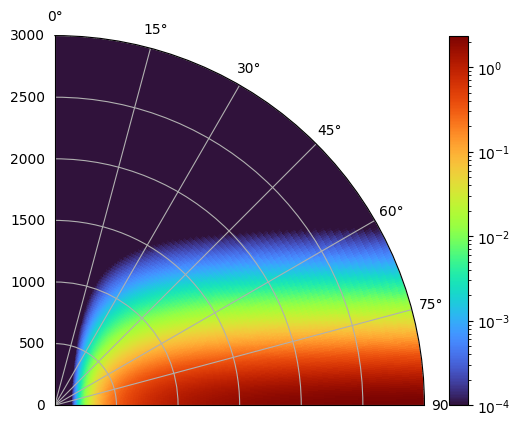

In [12]:
import matplotlib as mpl
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.densprof, norm=mpl.colors.LogNorm(vmin=1e-4))
#s = ax.pcolormesh(prof.grid[ 1 ], prof.grid[ 0 ], prof.velprof )#, norm=mpl.colors.LogNorm(vmin=1e-4))
plt.ylim([0,3000])
plt.xlim([0,np.pi/2])
plt.colorbar(s)


In [8]:
fname = "../../init/galaxy_init.bin"
IC( prof, fname, use_background=False )

[512 256]


[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan na

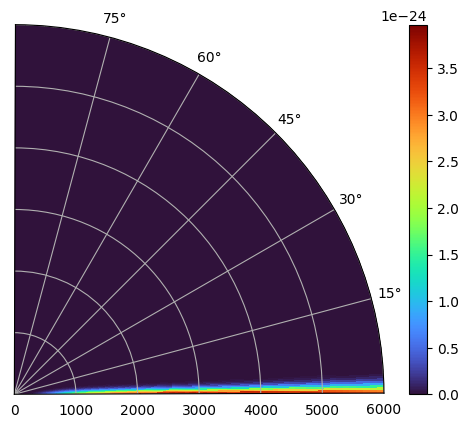

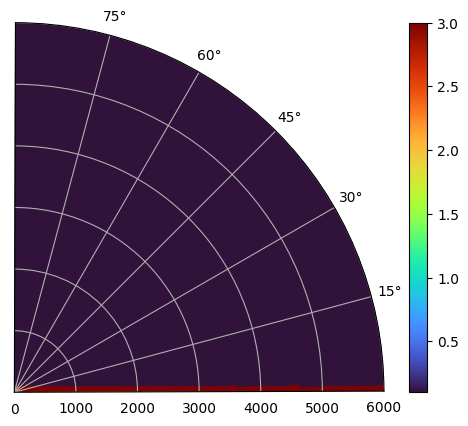

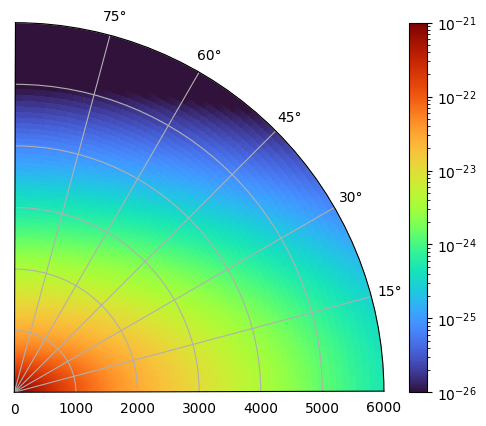

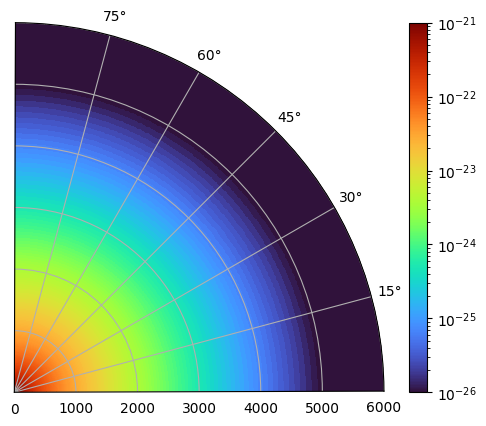

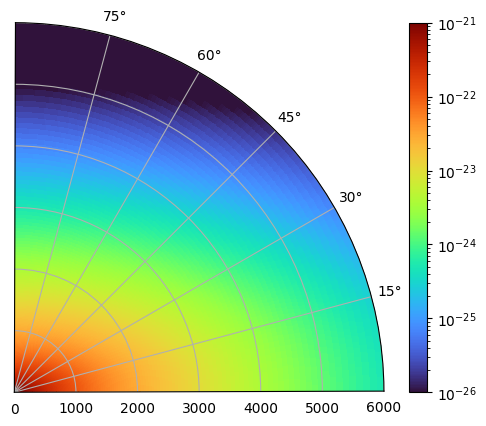

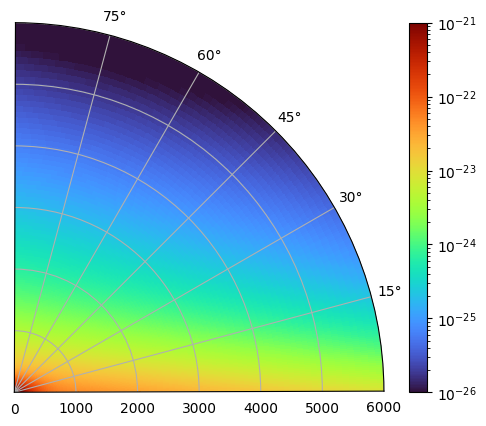

In [15]:
############################################################
# Check the data generating results
##############################
from matplotlib.pyplot import figure, pcolormesh
from numpy import pi

pc = units.pc

tst = binary_io( "../outputs/init_cond/cmz_init.bin" );
tst.open(  );
tst.read(  );

nfig = 0
########################################
# Hydro init cond

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_rho' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd )#, norm =
                     #LogNorm( vmin = 1e-26, vmax= 1e-21 ) )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])

########################################
# Hydro init cond met

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );

aa = tst.as_array( 'hydro_met' );
rr = tst.as_array( 'hydro_x_0'  );
tt = pi / 2 - tst.as_array( 'hydro_x_1'  );
# pi / 2 - theta for plots only! In Python's polar grid
# the polar angule is actually the latitutde

dd = aa.reshape( len( rr ), len( tt ) );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd )#, norm =
                     #LogNorm( vmin = 1e-26, vmax= 1e-21 ) )
cbar = fig.colorbar( pcm )
ax.set_ylim( 0, 6000 )
print(dd[np.isnan(dd)])
########################################
# Bar field

aa = tst.as_array( 'bar_data' );
rr = tst.as_array( 'bar_x_0'  );
tt = pi / 2 - tst.as_array( 'bar_x_1'  );
pp = tst.as_array( 'bar_x_2'  );
dd = aa.reshape( len( rr ), len( tt ), len( pp ) );

# Plot the r--theta slices
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, 0 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd[ :, :, -1 ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

# Plot the equatorial plance profile
fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( pp.min(  ), pp.max(  ) )
pcm = ax.pcolormesh( pp, rr / pc, dd[ :, -1, : ],
                     norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )
cbar = fig.colorbar( pcm )

print(dd[np.isnan(dd)])
########################################
# BG DM field

aa = tst.as_array( 'bg_data' );
rr = tst.as_array( 'bg_x_0'  );
tt = pi / 2 - tst.as_array( 'bg_x_1'  );
dd = aa.reshape( len( rr ), len( tt ) );

fig = figure( nfig )
nfig += 1
ax  = fig.add_subplot( 111, projection = 'polar' );
ax.set_xlim( tt.min(  ), tt.max(  ) )
pcm = ax.pcolormesh( tt, rr / pc, dd, norm = LogNorm
                     ( vmin = 1e-26, vmax= 1e-21 ) )
ax.set_ylim( 0, 6000 )

cbar = fig.colorbar( pcm )
##############################
# Close the binary_io object
print(dd[np.isnan(dd)])
tst.close(  );
#plt.savefig("test.png",dpi=300)
############################################################